# Visualizations of loss Function

In [1]:
import sys
import os
main_dir = os.path.dirname(os.getcwd())
sys.path.append(main_dir)

import argparse
import os
import time

import numpy as np

from MambaCD.changedetection.configs.config import get_config

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from MambaCD.changedetection.datasets.make_data_loader import SemanticChangeDetectionDatset, make_data_loader
from MambaCD.changedetection.utils_func.metrics import Evaluator
from MambaCD.changedetection.models.STMambaSCD import STMambaSCD
import MambaCD.changedetection.utils_func.lovasz_loss as L
from torch.optim.lr_scheduler import StepLR

from MambaCD.changedetection.utils_func.mcd_utils import accuracy, SCDD_eval_all, AverageMeter
from ChangeDetection.CDlib.loss import ce2_dice1, ce2_dice1_multiclass
import matplotlib.pyplot as plt

/userhomes/keshawa17/CD/MambaCD/classification/models/vmamba.py:252: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/userhomes/keshawa17/CD/MambaCD/classification/models/vmamba.py:260: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/userhomes/keshawa17/CD/MambaCD/classification/models/vmamba.py:275: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/userhomes/keshawa17/CD/MambaCD/classification/models/vmamba.py:283: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/userhomes/keshawa17/CD/MambaCD/classification/model

In [2]:
torch.cuda.set_device(0)

In [3]:
MODEL_PATH = os.path.join(
    main_dir, "MambaCD/saved_models/SECOND/MambaSCD_1738611602.5036116/12000_model.pth"
)

In [4]:
configs_path = os.path.join(main_dir, 'MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml')
model_path = os.path.join(main_dir, 'MambaCD/saved_models')

SECOND_DATASET_PATH = os.path.join(main_dir, 'Datasets', 'SECOND')
SECOND_TRAIN_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'train')
SECOND_TEST_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'test')
SECOND_TRAIN_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'train.txt')
SECOND_TEST_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'test.txt')

train_data_list = []
with open(SECOND_TRAIN_DATA_LIST_PATH, 'r') as f:
    for line in f:
        train_data_list.append(line.strip())

test_data_list = []
with open(SECOND_TEST_DATA_LIST_PATH, 'r') as f:
    for line in f:
        test_data_list.append(line.strip())

class ARGS:
    def __init__(self):
        self.cfg = configs_path
        self.opts = None
        self.pretrained_weight_path = MODEL_PATH
        self.dataset = 'SECOND'
        self.type = 'train'
        self.train_dataset_path = SECOND_TRAIN_DATASET_PATH
        self.train_data_list_path = SECOND_TRAIN_DATA_LIST_PATH
        self.test_dataset_path = SECOND_TEST_DATASET_PATH
        self.test_data_list_path = SECOND_TEST_DATA_LIST_PATH
        self.shuffle = True
        self.batch_size = 1
        self.crop_size = 512
        self.train_data_name_list = train_data_list
        self.test_data_name_list = test_data_list
        self.start_iter = 0
        self.cuda = True
        self.max_iters = 400000
        self.model_type = 'MambaSCD'
        self.model_param_path = model_path
        self.resume = None
        self.learning_rate = 1e-4
        self.momentum = 0.9
        self.weight_decay = 5e-4

args = ARGS()

In [5]:
args = args
config = get_config(args)

train_data_loader = make_data_loader(args)

deep_model = STMambaSCD(
    output_cd = 2, 
    output_clf = 7,
    pretrained=args.pretrained_weight_path,
    patch_size=config.MODEL.VSSM.PATCH_SIZE, 
    in_chans=config.MODEL.VSSM.IN_CHANS, 
    num_classes=config.MODEL.NUM_CLASSES, 
    depths=config.MODEL.VSSM.DEPTHS, 
    dims=config.MODEL.VSSM.EMBED_DIM, 
    # ===================
    ssm_d_state=config.MODEL.VSSM.SSM_D_STATE,
    ssm_ratio=config.MODEL.VSSM.SSM_RATIO,
    ssm_rank_ratio=config.MODEL.VSSM.SSM_RANK_RATIO,
    ssm_dt_rank=("auto" if config.MODEL.VSSM.SSM_DT_RANK == "auto" else int(config.MODEL.VSSM.SSM_DT_RANK)),
    ssm_act_layer=config.MODEL.VSSM.SSM_ACT_LAYER,
    ssm_conv=config.MODEL.VSSM.SSM_CONV,
    ssm_conv_bias=config.MODEL.VSSM.SSM_CONV_BIAS,
    ssm_drop_rate=config.MODEL.VSSM.SSM_DROP_RATE,
    ssm_init=config.MODEL.VSSM.SSM_INIT,
    forward_type=config.MODEL.VSSM.SSM_FORWARDTYPE,
    # ===================
    mlp_ratio=config.MODEL.VSSM.MLP_RATIO,
    mlp_act_layer=config.MODEL.VSSM.MLP_ACT_LAYER,
    mlp_drop_rate=config.MODEL.VSSM.MLP_DROP_RATE,
    # ===================
    drop_path_rate=config.MODEL.DROP_PATH_RATE,
    patch_norm=config.MODEL.VSSM.PATCH_NORM,
    norm_layer=config.MODEL.VSSM.NORM_LAYER,
    downsample_version=config.MODEL.VSSM.DOWNSAMPLE,
    patchembed_version=config.MODEL.VSSM.PATCHEMBED,
    gmlp=config.MODEL.VSSM.GMLP,
    use_checkpoint=config.TRAIN.USE_CHECKPOINT,
    ) 

deep_model.load_state_dict(torch.load(MODEL_PATH))
deep_model.cuda()

=> merge config from /userhomes/keshawa17/CD/MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml


/userhomes/keshawa17/CD/MambaCD/changedetection/models/Mamba_backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _ckpt = torch.load(open(ckpt, "rb"), map_location=

Successfully load ckpt /userhomes/keshawa17/CD/MambaCD/saved_models/SECOND/MambaSCD_1738611602.5036116/12000_model.pth
Failed loading checkpoint form /userhomes/keshawa17/CD/MambaCD/saved_models/SECOND/MambaSCD_1738611602.5036116/12000_model.pth: 'model'
False


/tmp/ipykernel_2609968/3711684686.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  deep_model.load_state_dict(torch.load(MODEL_PATH))


STMambaSCD(
  (encoder): Backbone_VSSM(
    (patch_embed): Sequential(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Permute()
      (2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (3): Permute()
      (4): GELU(approximate='none')
      (5): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Permute()
      (7): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): Conv1DMamba_v2_Encoder(
            (vssmBlock): VSSBlock(
              (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (op): SS2D(
                (out_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                (in_proj): Linear(in_features=96, out_features=192, bias=False)
                (act): SiLU()
                (conv2d): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), gro

# Image Lib

In [6]:
ori_label_value_dict = {
    'background': (0, 0, 0),
    'low_vegetation': (0, 128, 0),
    'nvg_surface': (128, 128, 128),
    'tree': (0, 255, 0),
    'water': (0, 0, 255),
    'Building': (128, 0, 0),
    'Playground': (255, 0, 0)
}

target_label_value_dict = {
    'background': 0,
    'low_vegetation': 1,
    'nvg_surface': 2,
    'tree': 3,
    'water': 4,
    'Building': 5,
    'Playground': 6
}

def map_labels_to_colors(labels, ori_label_value_dict, target_label_value_dict):
    # Reverse the target_label_value_dict to get a mapping from target labels to original labels
    target_to_ori = {v: k for k, v in target_label_value_dict.items()}
    
    # Initialize an empty 3D array for the color-mapped labels
    H, W = labels.shape
    color_mapped_labels = np.zeros((H, W, 3), dtype=np.uint8)
    
    for target_label, ori_label in target_to_ori.items():
        # Find where the label matches the current target label
        mask = labels == target_label
        
        # Map these locations to the corresponding color value
        color_mapped_labels[mask] = ori_label_value_dict[ori_label]
    
    return color_mapped_labels

  0%|          | 0/400000 [00:00<?, ?it/s]

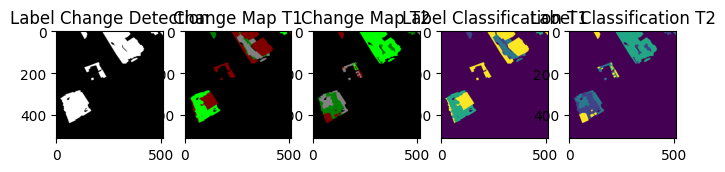

  0%|          | 0/400000 [00:00<?, ?it/s]


In [7]:
elem_num = len(train_data_loader)
train_enumerator = enumerate(train_data_loader)
for _ in tqdm(range(elem_num)):
    itera, data = train_enumerator.__next__()
    pre_change_imgs, post_change_imgs, label_cd, label_clf_t1, label_clf_t2, _ = data

    pre_change_imgs = pre_change_imgs.cuda()
    post_change_imgs = post_change_imgs.cuda()
    label_cd = label_cd.cuda().long()
    label_clf_t1 = label_clf_t1.cuda().long()
    label_clf_t2 = label_clf_t2.cuda().long()

    change_map_T1 = map_labels_to_colors(np.squeeze(label_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
    change_map_T2 = map_labels_to_colors(np.squeeze(label_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

    fig1, axes = plt.subplots(1, 5, figsize=(8, 4))
    axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
    axes[0].set_title('Label Change Detection')
    axes[1].imshow(change_map_T1)
    axes[1].set_title('Change Map T1')
    axes[2].imshow(change_map_T2)
    axes[2].set_title('Change Map T2')
    axes[3].imshow(label_clf_t1[0].cpu().numpy())
    axes[3].set_title('Label Classification T1')
    axes[4].imshow(label_clf_t2[0].cpu().numpy())
    axes[4].set_title('Label Classification T2')
    plt.show()
    break

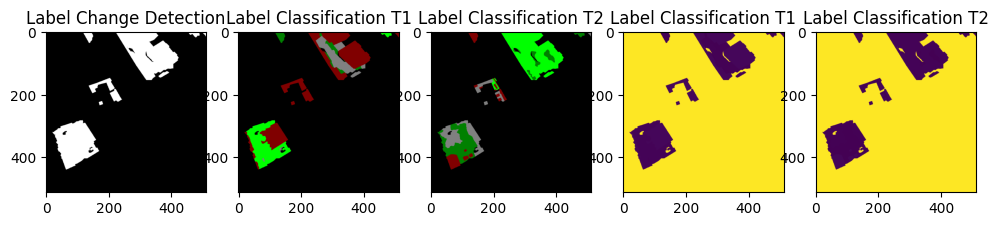

In [8]:
label_clf_t1[label_clf_t1 == 0] = 255
label_clf_t2[label_clf_t2 == 0] = 255

change_map_T1 = map_labels_to_colors(np.squeeze(label_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
change_map_T2 = map_labels_to_colors(np.squeeze(label_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig1, axes = plt.subplots(1, 5, figsize=(12, 4))
axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(change_map_T1)
axes[1].set_title('Label Classification T1')
axes[2].imshow(change_map_T2)
axes[2].set_title('Label Classification T2')
axes[3].imshow(label_clf_t1[0].cpu().numpy())
axes[3].set_title('Label Classification T1')
axes[4].imshow(label_clf_t2[0].cpu().numpy())
axes[4].set_title('Label Classification T2')
plt.show()

In [9]:
output_1, output_semantic_t1_, output_semantic_t2_ = deep_model(pre_change_imgs, post_change_imgs)

In [10]:
output_semantic_t1 = output_semantic_t1_
output_semantic_t2 = output_semantic_t2_

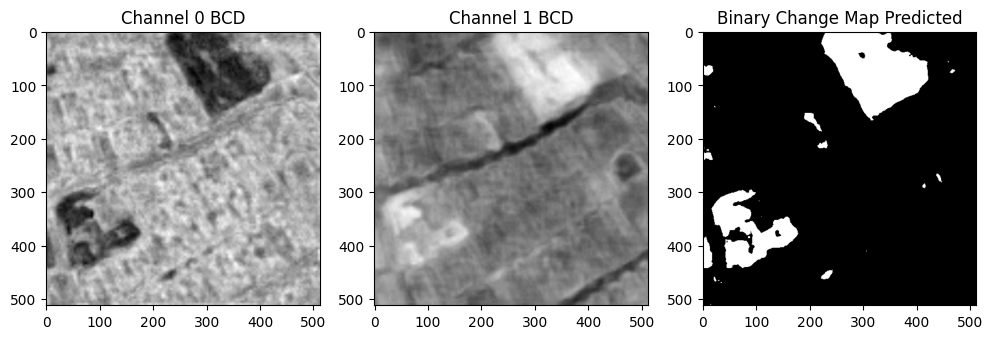

In [11]:
change_mask = torch.argmax(output_1, axis=1)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(output_1[0][0].cpu().detach().numpy(), cmap='gray')
axes[0].set_title('Channel 0 BCD')
axes[1].imshow(output_1[0][1].cpu().detach().numpy(), cmap='gray')
axes[1].set_title('Channel 1 BCD')
axes[2].imshow(change_mask[0].cpu().detach().numpy(), cmap='gray')
axes[2].set_title('Binary Change Map Predicted')
plt.show()

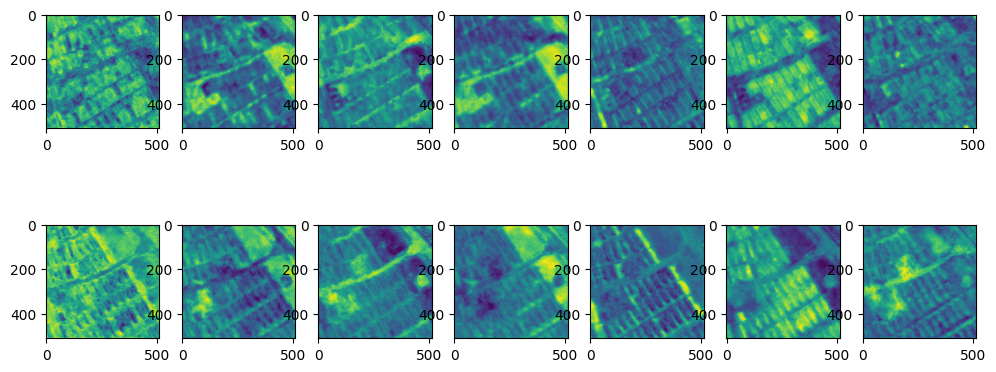

In [12]:
fig, axes = plt.subplots(2, 7, figsize=(12, 5))
for i in range(7):
    axes[0, i].imshow(output_semantic_t1[0][i].cpu().detach().numpy())
    axes[1, i].imshow(output_semantic_t2[0][i].cpu().detach().numpy())
plt.show()

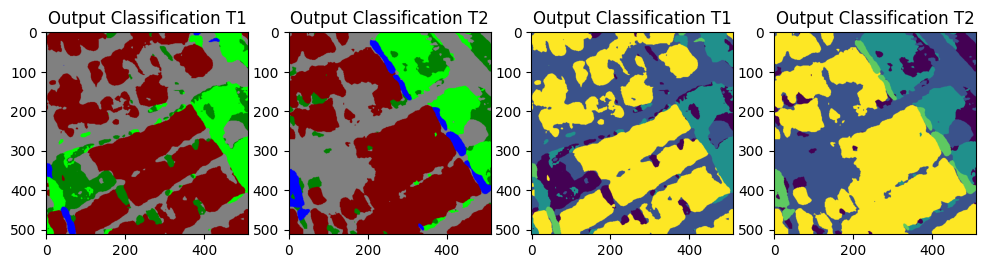

In [13]:
output_semantic_t1_pred = torch.argmax(output_semantic_t1, dim=1)
output_semantic_t2_pred = torch.argmax(output_semantic_t2, dim=1)

change_map_T1 = map_labels_to_colors(np.squeeze(output_semantic_t1_pred.cpu().detach().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
change_map_T2 = map_labels_to_colors(np.squeeze(output_semantic_t2_pred.cpu().detach().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes[0].imshow(change_map_T1)
axes[0].set_title('Output Classification T1')
axes[1].imshow(change_map_T2)
axes[1].set_title('Output Classification T2')
axes[2].imshow(output_semantic_t1_pred[0].cpu().detach().numpy())
axes[2].set_title('Output Classification T1')
axes[3].imshow(output_semantic_t2_pred[0].cpu().detach().numpy())
axes[3].set_title('Output Classification T2')

plt.show()

# Loss

In [14]:
similarity_mask = (label_clf_t1 == 255).float().unsqueeze(1).expand_as(output_semantic_t1)
similarity_loss = F.mse_loss(F.softmax(output_semantic_t1, dim=1) * similarity_mask, F.softmax(output_semantic_t2, dim=1) * similarity_mask, reduction='mean')

print(f"Similarity Loss: {similarity_loss}")

# ce_loss_cd = F.cross_entropy(output_1, label_cd, ignore_index=255)
ce_loss_cd = ce2_dice1(output_1, label_cd)
print(f"CE Loss CD: {ce_loss_cd}")

lovasz_loss_cd = L.lovasz_softmax(F.softmax(output_1, dim=1), label_cd, ignore=255)
print(f"Lovasz Loss CD: {lovasz_loss_cd}")

lovasz_loss_clf_t1 = L.lovasz_softmax(F.softmax(output_semantic_t1, dim=1), label_clf_t1, ignore=255)
print(f"Lovasz Loss Clf T1: {lovasz_loss_clf_t1}")
ce_loss_clf_t1 = F.cross_entropy(output_semantic_t1, label_clf_t1,ignore_index=255)
ce_loss_clf_t1 = ce2_dice1_multiclass(output_semantic_t1, label_clf_t1)
print(f"CE Loss Clf T1: {ce_loss_clf_t1}")

lovasz_loss_clf_t2 = L.lovasz_softmax(F.softmax(output_semantic_t2, dim=1), label_clf_t2, ignore=255)
print(f"Lovasz Loss Clf T2: {lovasz_loss_clf_t2}")
ce_loss_clf_t2 = F.cross_entropy(output_semantic_t2, label_clf_t2, ignore_index=255)
# ce_loss_clf_t2 = ce2_dice1_multiclass(output_semantic_t2, label_clf_t2)
print(f"CE Loss Clf T2: {ce_loss_clf_t2}")

Similarity Loss: 0.029309973120689392
CE Loss CD: 0.34927546977996826
Lovasz Loss CD: 0.26912885904312134
Lovasz Loss Clf T1: 0.6143503189086914
CE Loss Clf T1: 0.9323853254318237
Lovasz Loss Clf T2: 0.515386164188385
CE Loss Clf T2: 0.82679283618927


torch.Size([1, 7, 512, 512])
torch.Size([227885])


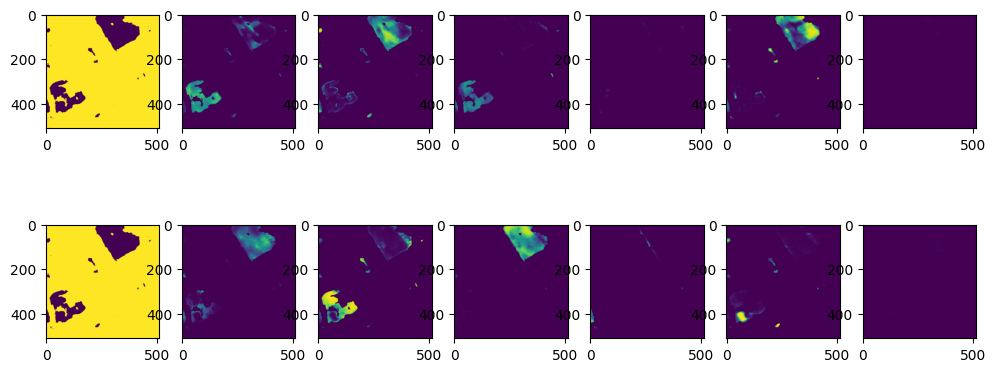

In [19]:
mask_0 = (change_mask == 0).unsqueeze(1).expand_as(output_semantic_t1)

output_semantic_t1_copy = output_semantic_t1.clone()
output_semantic_t2_copy = output_semantic_t2.clone()

T1_probs = F.softmax(output_semantic_t1_copy, dim=1)
T2_probs = F.softmax(output_semantic_t2_copy, dim=1)

T1_probs[mask_0==1] = 1e-5
T2_probs[mask_0==1] = 1e-5

print(T1_probs.shape)
print(T1_probs[mask_0==0].shape)

T1_probs[:,0,:,:][mask_0[:,0,:,:]] = 1-1e-5
T2_probs[:,0,:,:][mask_0[:,0,:,:]] = 1-1e-5

fig, axes = plt.subplots(2, 7, figsize=(12, 5))
for i in range(7):
    axes[0, i].imshow(T1_probs[0][i].cpu().detach().numpy(),vmin=0, vmax=1)
    axes[1, i].imshow(T2_probs[0][i].cpu().detach().numpy(),vmin=0, vmax=1)
plt.show()

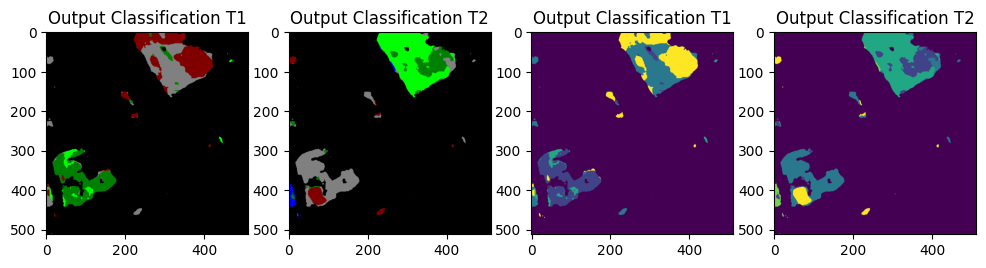

In [20]:
output_semantic_t1_pred = torch.argmax(T1_probs, dim=1)
output_semantic_t2_pred = torch.argmax(T2_probs, dim=1)

change_map_T1 = map_labels_to_colors(np.squeeze(output_semantic_t1_pred.cpu().detach().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
change_map_T2 = map_labels_to_colors(np.squeeze(output_semantic_t2_pred.cpu().detach().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes[0].imshow(change_map_T1)
axes[0].set_title('Output Classification T1')
axes[1].imshow(change_map_T2)
axes[1].set_title('Output Classification T2')
axes[2].imshow(output_semantic_t1_pred[0].cpu().detach().numpy())
axes[2].set_title('Output Classification T1')
axes[3].imshow(output_semantic_t2_pred[0].cpu().detach().numpy())
axes[3].set_title('Output Classification T2')

plt.show()

# Loss

In [21]:
similarity_mask = (label_clf_t1 == 255).float().unsqueeze(1).expand_as(output_semantic_t1)
similarity_loss = F.mse_loss(F.softmax(output_semantic_t1, dim=1) * similarity_mask, F.softmax(output_semantic_t2, dim=1) * similarity_mask, reduction='mean')

print(f"Similarity Loss: {similarity_loss}")

# ce_loss_cd = F.cross_entropy(output_1, label_cd, ignore_index=255)
ce_loss_cd = ce2_dice1(output_1, label_cd)
print(f"CE Loss CD: {ce_loss_cd}")

lovasz_loss_cd = L.lovasz_softmax(F.softmax(output_1, dim=1), label_cd, ignore=255)
print(f"Lovasz Loss CD: {lovasz_loss_cd}")

lovasz_loss_clf_t1 = L.lovasz_softmax(T1_probs, label_clf_t1, ignore=255)
print(f"Lovasz Loss Clf T1: {lovasz_loss_clf_t1}")
ce_loss_clf_t1 = F.cross_entropy(torch.log(T1_probs), label_clf_t1,ignore_index=255)
# ce_loss_clf_t1 = ce2_dice1_multiclass(torch.log(T1_probs), label_clf_t1)
print(f"CE Loss Clf T1: {ce_loss_clf_t1}")

lovasz_loss_clf_t2 = L.lovasz_softmax(T2_probs, label_clf_t2, ignore=255)
print(f"Lovasz Loss Clf T2: {lovasz_loss_clf_t2}")
ce_loss_clf_t2 = F.cross_entropy(torch.log(T2_probs), label_clf_t2,ignore_index=255)
# ce_loss_clf_t2 = ce2_dice1_multiclass(torch.log(T2_probs), label_clf_t2)
print(f"CE Loss Clf T2: {ce_loss_clf_t2}")

Similarity Loss: 0.029309973120689392
CE Loss CD: 0.34927546977996826
Lovasz Loss CD: 0.26912885904312134
Lovasz Loss Clf T1: 0.6644776463508606
CE Loss Clf T1: 3.7510130405426025
Lovasz Loss Clf T2: 0.6621789932250977
CE Loss Clf T2: 3.756962537765503


# Validation

In [18]:
S = False
if S:
    dataset = SemanticChangeDetectionDatset(args.test_dataset_path, args.test_data_name_list, 256, None, 'test')
    val_data_loader = DataLoader(dataset, batch_size=5, num_workers=4, drop_last=False)
    torch.cuda.empty_cache()
    acc_meter = AverageMeter()

    preds_all = []
    labels_all = []
    with torch.no_grad():
        for itera, data in enumerate(val_data_loader):
            pre_change_imgs, post_change_imgs, labels_cd, labels_clf_t1, labels_clf_t2, _ = data

            pre_change_imgs = pre_change_imgs.cuda()
            post_change_imgs = post_change_imgs.cuda()
            labels_cd = labels_cd.cuda().long()
            labels_clf_t1 = labels_clf_t1.cuda().long()
            labels_clf_t2 = labels_clf_t2.cuda().long()


            # input_data = torch.cat([pre_change_imgs, post_change_imgs], dim=1)
            output_1, output_semantic_t1, output_semantic_t2 = deep_model(pre_change_imgs, post_change_imgs)

            labels_cd = labels_cd.cpu().numpy()
            labels_A = labels_clf_t1.cpu().numpy()
            labels_B = labels_clf_t2.cpu().numpy()

            change_mask = torch.argmax(output_1, axis=1).cpu().numpy()

            preds_A = torch.argmax(output_semantic_t1, dim=1).cpu().numpy()
            preds_B = torch.argmax(output_semantic_t2, dim=1).cpu().numpy()
            
            preds_A[change_mask == 0] = 0
            preds_B[change_mask == 0] = 0

            for (pred_A, pred_B, label_A, label_B) in zip(preds_A, preds_B, labels_A, labels_B):
                acc_A, valid_sum_A = accuracy(pred_A, label_A)
                acc_B, valid_sum_B = accuracy(pred_B, label_B)
                preds_all.append(pred_A)
                preds_all.append(pred_B)
                labels_all.append(label_A)
                labels_all.append(label_B)
                acc = (acc_A + acc_B) * 0.5
                acc_meter.update(acc)

    kappa_n0, Fscd, IoU_mean, Sek = SCDD_eval_all(preds_all, labels_all, 37)
    print(f'Kappa coefficient rate is {kappa_n0}, F1 is {Fscd}, OA is {acc_meter.avg}, '
            f'mIoU is {IoU_mean}, SeK is {Sek}')